In [44]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as web
import datetime as dt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, InputLayer

In [45]:

pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [46]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [47]:
pip install numpy matplotlib pandas pandas_datareader tensorflow scikit-learn keras


Note: you may need to restart the kernel to use updated packages.


In [48]:
pip install numpy


Note: you may need to restart the kernel to use updated packages.


In [49]:
pip install numpy pandas matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [50]:
import os
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#------------------------------------------------------------------------------
# Production-Ready Multi-Feature Stock Data Loader
#------------------------------------------------------------------------------
def load_and_process_stock_data(
    company="CBA.AX",
    start_date="2020-01-01",
    end_date="2023-08-01",
    data_dir="data",
    handle_nan="drop",       # "drop", "ffill", "bfill", "mean"
    split_method="ratio",    # "ratio", "date", "random"
    split_value=0.8,         # float for ratio, string for date
    scale_features=True,
    scaler_type="standard",  # "standard" or "minmax"
    save_local=True,
    load_local=True
):
    """
    Load, clean, split, and scale stock data (multi-feature) with proper error handling.
    """

    #--------------------------------------------------------------
    # Step 0: Validate dates
    #--------------------------------------------------------------
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    if start_date >= end_date:
        raise ValueError("Start date must be earlier than end date.")

    #--------------------------------------------------------------
    # Step 1: Prepare local file path
    #--------------------------------------------------------------
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
    csv_file = os.path.join(data_dir, f"{company}_stock_data.csv")

    #--------------------------------------------------------------
    # Step 2: Load dataset
    #--------------------------------------------------------------
    data = pd.DataFrame()
    if load_local and os.path.exists(csv_file):
        try:
            data = pd.read_csv(csv_file, index_col="Date", parse_dates=True)
            if data.empty:
                print(f"⚠️ Local file exists but is empty. Will attempt download.")
                data = pd.DataFrame()
            else:
                print(f"✅ Loaded local file: {csv_file}")
        except Exception as e:
            print(f"⚠️ Failed to load local file: {e}. Will attempt download.")

    if data.empty:
        try:
            data = yf.download(company, start=start_date, end=end_date)
            if data.empty:
                raise ValueError("Downloaded dataset is empty. Check ticker or date range.")
            if save_local:
                data.to_csv(csv_file)
                print(f"✅ Downloaded and saved to {csv_file}")
        except Exception as e:
            raise ConnectionError(f"❌ Failed to download data: {e}")

    #--------------------------------------------------------------
    # Step 3: Standardize column names
    #--------------------------------------------------------------
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = [col[0] for col in data.columns]  # flatten MultiIndex
    data.columns = data.columns.str.strip().str.title().str.replace(" ", "")

    # Example result: ['Open','High','Low','Close','Adjclose','Volume']

    #--------------------------------------------------------------
    # Step 4: Handle missing values
    #--------------------------------------------------------------
    if handle_nan == "drop":
        data = data.dropna()
    elif handle_nan == "ffill":
        data = data.ffill()
    elif handle_nan == "bfill":
        data = data.bfill()
    elif handle_nan == "mean":
        data = data.fillna(data.mean())
    else:
        raise ValueError("Invalid handle_nan option.")

    #--------------------------------------------------------------
    # Step 5: Feature scaling (per-column)
    #--------------------------------------------------------------
    scalers = {}
    if scale_features:
        scaled_data = pd.DataFrame(index=data.index)
        for col in data.columns:
            if scaler_type == "standard":
                scaler = StandardScaler()
            elif scaler_type == "minmax":
                scaler = MinMaxScaler()
            else:
                raise ValueError("Invalid scaler_type: 'standard' or 'minmax'")
            
            scaled_data[col] = scaler.fit_transform(data[[col]])
            scalers[col] = scaler
        data = scaled_data

    #--------------------------------------------------------------
    # Step 6: Train/Test Split
    #--------------------------------------------------------------
    if split_method == "ratio":
        split_idx = int(len(data) * split_value)
        train = data.iloc[:split_idx]
        test = data.iloc[split_idx:]
    
    elif split_method == "date":
        split_date = pd.to_datetime(split_value)
        train = data[data.index < split_date]
        test = data[data.index >= split_date]
    
    elif split_method == "random":
        train = data.sample(frac=split_value, random_state=42)
        test = data.drop(train.index)
    else:
        raise ValueError("Invalid split_method: 'ratio', 'date', 'random' only")

    return train, test, scalers


#------------------------------------------------------------------------------
# Example Usage
#------------------------------------------------------------------------------
if __name__ == "__main__":
    train_data, test_data, scalers = load_and_process_stock_data(
        company="CBA.AX",
        start_date="2020-01-01",
        end_date="2023-08-01",
        handle_nan="ffill",
        split_method="date",
        split_value="2023-01-01",
        scale_features=True,
        scaler_type="minmax",
        save_local=True,
        load_local=False   # force re-download to avoid empty file issue
    )

    print("Train shape:", train_data.shape)
    print("Test shape:", test_data.shape)
    print("Columns:", train_data.columns.tolist())
    print(train_data.head())


/var/folders/n3/f5ytszns27bb7c95jm3qrfdh0000gn/T/ipykernel_83530/1392883563.py:58: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(company, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

✅ Downloaded and saved to data/CBA.AX_stock_data.csv
Train shape: (760, 5)
Test shape: (145, 5)
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']
               Close      High       Low      Open    Volume
Date                                                        
2020-01-02  0.354186  0.322016  0.359309  0.335333  0.063919
2020-01-03  0.360431  0.336813  0.371800  0.352911  0.076308
2020-01-06  0.352589  0.316830  0.356985  0.334439  0.106688
2020-01-07  0.373355  0.336965  0.370783  0.350677  0.123976
2020-01-08  0.368998  0.337728  0.368604  0.356635  0.082087


In [51]:
# Select the column you want to predict
PRICE_VALUE = "Close"

# scaled_data is just the values of that column from train_data
scaled_data = train_data[[PRICE_VALUE]].values

PREDICTION_DAYS = 60
x_train, y_train = [], []

for i in range(PREDICTION_DAYS, len(scaled_data)):
    x_train.append(scaled_data[i-PREDICTION_DAYS:i])
    y_train.append(scaled_data[i])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)


x_train shape: (700, 60, 1)
y_train shape: (700, 1)


In [52]:
#-------------------- Build the LSTM Model --------------------#
model = Sequential()

# Input layer: shape matches number of past days used for prediction
model.add(InputLayer(input_shape=(x_train.shape[1], 1)))

# First LSTM layer with Dropout for regularization
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Second LSTM layer with Dropout
model.add(LSTM(units=50))
model.add(Dropout(0.2))

# Output layer: predicts a single value (next price)
model.add(Dense(1))

# Compile the model with optimizer and loss function
model.compile(optimizer='adam', loss='mean_squared_error')

#-------------------- Train the Model --------------------#
# We train the model on x_train, y_train
# validation_split=0.1 uses 10% of the training data for validation
# verbose=1 prints training progress
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

#-------------------- Save the Model --------------------#
# After training, save the model to reuse later without retraining
model.save("results/CBA_AX_model.h5")


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.1337 - val_loss: 0.0350
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0137 - val_loss: 0.0024
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0073 - val_loss: 0.0030
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0057 - val_loss: 0.0035
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0061 - val_loss: 0.0032
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0057 - val_loss: 0.0028
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0056 - val_loss: 0.0023
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0054 - val_loss: 0.0017
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0056 - val_loss: 0.0030
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0054 - val_loss: 0.0029
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0056 - val_loss: 0.0031
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0

In [53]:
#------------------------------------------------------------------------------
# Test the model accuracy on existing data
#------------------------------------------------------------------------------
COMPANY = "CBA.AX"
TEST_START = "2020-01-01"
TEST_END = "2023-08-11"

# Download the test data
test_data = yf.download(COMPANY, TEST_START, TEST_END)

# Get actual closing prices
actual_prices = test_data[PRICE_VALUE].values

# Combine training + test column for consistent scaling
total_dataset = pd.concat((train_data[PRICE_VALUE], test_data[PRICE_VALUE]), axis=0)

# Prepare model inputs (last PREDICTION_DAYS from train + all test values)
model_inputs = total_dataset[len(total_dataset) - len(test_data) - PREDICTION_DAYS:].values

# Reshape for scaler
model_inputs = model_inputs.reshape(-1, 1)

# Use same scaler (from training) to transform inputs
scaler = scalers[PRICE_VALUE]   # reuse existing scaler
model_inputs = scaler.transform(model_inputs)

# Prepare x_test sequences
x_test = []
for i in range(PREDICTION_DAYS, len(model_inputs)):
    x_test.append(model_inputs[i - PREDICTION_DAYS:i, 0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Predict
predicted_prices = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted_prices)



/var/folders/n3/f5ytszns27bb7c95jm3qrfdh0000gn/T/ipykernel_83530/3804805779.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test_data = yf.download(COMPANY, TEST_START, TEST_END)
[*********************100%***********************]  1 of 1 completed
/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


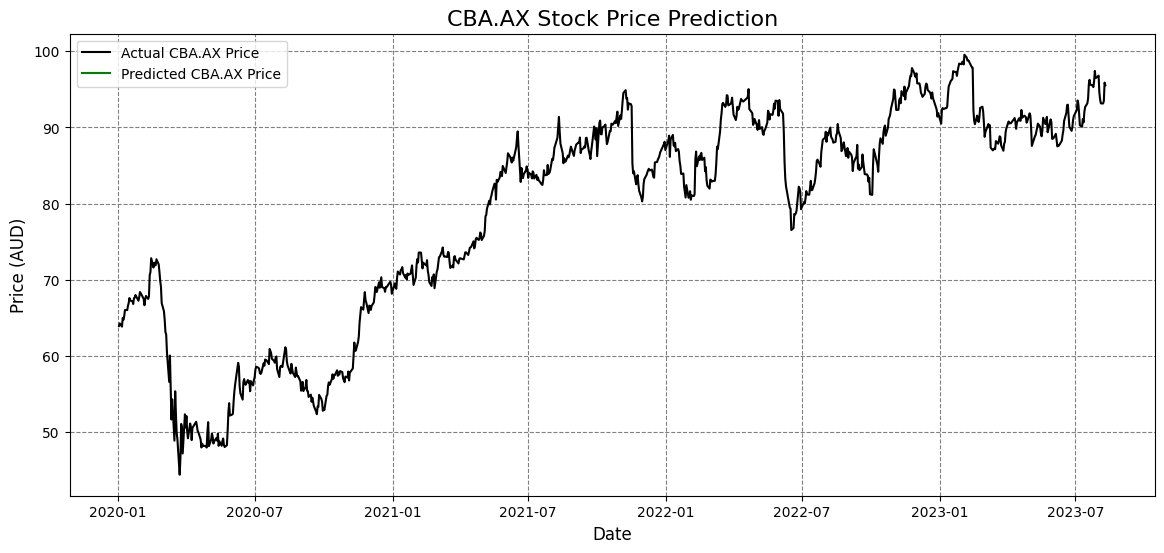

In [54]:
# Trim predicted prices to same length as test_data
predicted_prices = predicted_prices[-len(test_data):]

# Now they align perfectly
plt.figure(figsize=(14, 6))
plt.plot(test_data.index, actual_prices, color="black", label=f"Actual {COMPANY} Price")
plt.plot(test_data.index, predicted_prices, color="green", label=f"Predicted {COMPANY} Price")
plt.title(f"{COMPANY} Stock Price Prediction", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (AUD)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


ValueError: zero-size array to reduction operation maximum which has no identity

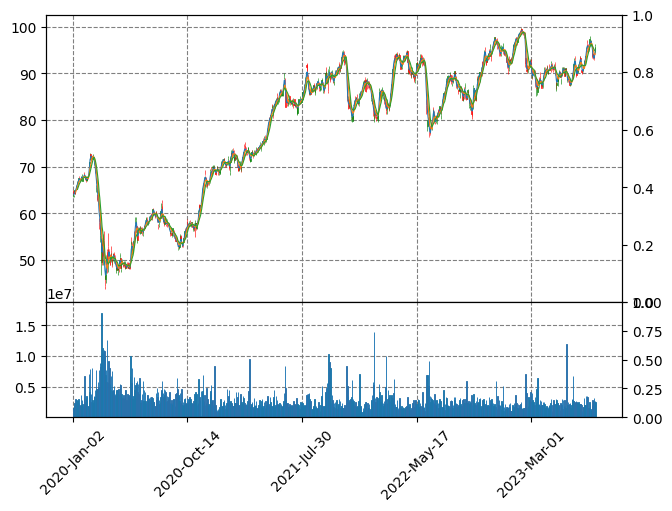

In [55]:
import mplfinance as mpf
import pandas as pd

# Copy test data (OHLCV)
ohlc_data = test_data.copy()

# Flatten MultiIndex columns if present (sometimes happens with yfinance)
if isinstance(ohlc_data.columns, pd.MultiIndex):
    ohlc_data.columns = [col[0] for col in ohlc_data.columns]

# Ensure OHLC columns are numeric
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    if col in ohlc_data.columns:
        ohlc_data[col] = pd.to_numeric(ohlc_data[col], errors='coerce')
    else:
        raise ValueError(f"Column '{col}' not found in test data!")

# Drop NaN rows (important for mplfinance)
ohlc_data.dropna(inplace=True)

# ⚡ FIX: Align predicted prices with test data length
predicted_prices = predicted_prices[-len(ohlc_data):]

# Create a series of predicted prices aligned to the last N rows of ohlc_data
ohlc_data['Predicted'] = pd.Series(
    predicted_prices.flatten(),
    index=ohlc_data.index[-len(predicted_prices):]
)

# Custom style for candlesticks
mc = mpf.make_marketcolors(up='g', down='r', edge='i', wick='i', volume='in')
s = mpf.make_mpf_style(marketcolors=mc, gridstyle='--', gridcolor='gray')

# Create an additional plot (Predicted line overlay)
add_plot = mpf.make_addplot(ohlc_data['Predicted'], color='blue', width=1.2)

# Plot candlestick chart with predicted prices overlay
mpf.plot(
    ohlc_data,
    type='candle',
    style=s,
    title=f"{COMPANY} Candlestick Chart with Predicted Prices",
    ylabel='Price (AUD)',
    volume=True,
    mav=(3, 6, 9),          # Moving averages (3, 6, 9 days)
    addplot=add_plot        # Overlay predicted prices
)


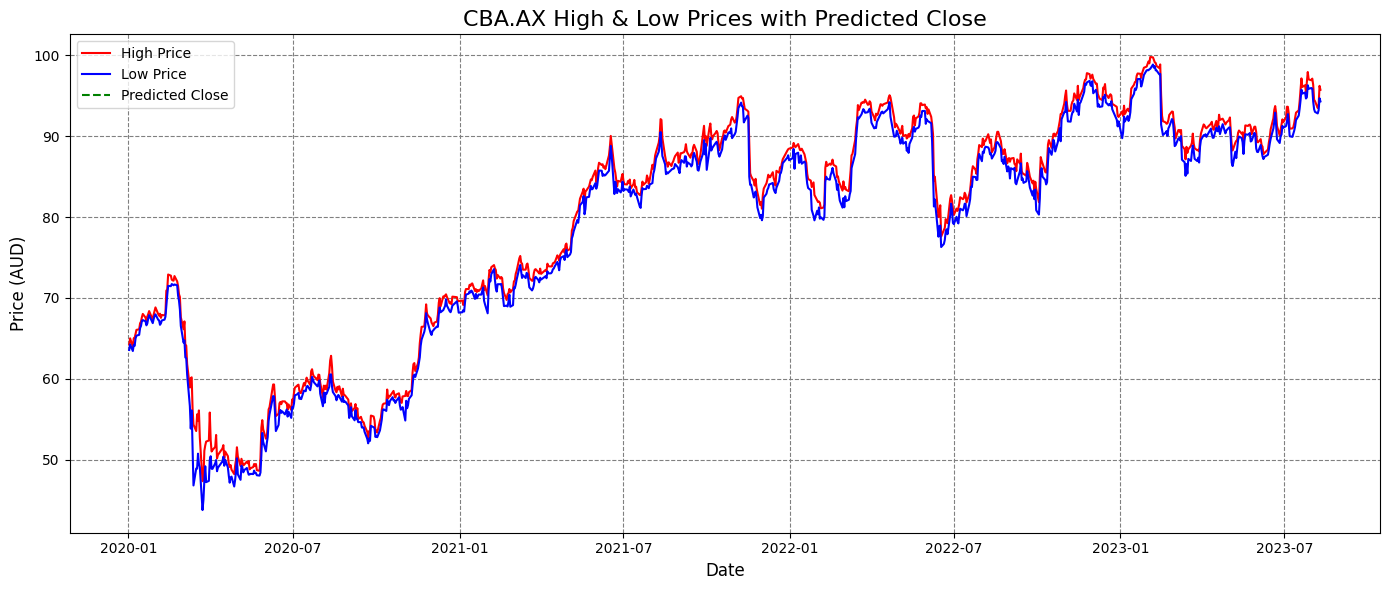

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Plot daily High prices
plt.plot(test_data.index, test_data['High'], color='red', label='High Price')

# Plot daily Low prices
plt.plot(test_data.index, test_data['Low'], color='blue', label='Low Price')

# Optional: overlay predicted Close prices
plt.plot(test_data.index, predicted_prices, color='green', linestyle='--', label='Predicted Close')

# Titles and labels
plt.title(f"{COMPANY} High & Low Prices with Predicted Close", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (AUD)", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Dense, Dropout

def build_dl_model(input_shape, layer_type='LSTM', layer_sizes=[50,50], dropout_rate=0.2, output_size=1):
    """
    Builds a Deep Learning model with configurable layers.
    
    Parameters:
        input_shape (tuple): Shape of input data (timesteps, features)
        layer_type (str): Type of recurrent layer ('LSTM', 'GRU', 'RNN')
        layer_sizes (list): List containing the number of units in each layer
        dropout_rate (float): Fraction of units to drop for regularization
        output_size (int): Number of output neurons (1 for regression)
    
    Returns:
        model (tf.keras.Model): Compiled Keras model
    """
    # Initialize Sequential model
    model = Sequential()
    
    # Add recurrent layers
    for i, size in enumerate(layer_sizes):
        return_sequences = i < len(layer_sizes) - 1  # True for all layers except last
        if layer_type == 'LSTM':
            model.add(LSTM(size, return_sequences=return_sequences, input_shape=input_shape if i==0 else None))
        elif layer_type == 'GRU':
            model.add(GRU(size, return_sequences=return_sequences, input_shape=input_shape if i==0 else None))
        elif layer_type == 'RNN':
            model.add(SimpleRNN(size, return_sequences=return_sequences, input_shape=input_shape if i==0 else None))
        else:
            raise ValueError("Invalid layer_type. Choose 'LSTM', 'GRU', or 'RNN'.")
        model.add(Dropout(dropout_rate))  # Regularization to prevent overfitting

    # Output layer for regression
    model.add(Dense(output_size))
    
    # Compile model
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model


In [58]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, GRU, SimpleRNN, InputLayer

def build_dl_model(
    input_shape,
    layer_type="LSTM",       # choose: "LSTM", "GRU", or "RNN"
    layer_sizes=(50, 50),    # hidden units per layer
    dropout_rate=0.2,
    output_size=1,
    optimizer="adam",
    loss="mean_squared_error"
):
    """
    Build and compile a Deep Learning model dynamically.

    Parameters
    ----------
    input_shape : tuple
        Shape of the input (timesteps, features).
    layer_type : str
        Type of recurrent layer: "LSTM", "GRU", or "RNN".
    layer_sizes : tuple
        Number of units in each layer. Length = number of layers.
    dropout_rate : float
        Dropout rate after each recurrent layer.
    output_size : int
        Size of output layer (1 for regression).
    optimizer : str
        Optimizer to use for training.
    loss : str
        Loss function.

    Returns
    -------
    model : keras.Sequential
        A compiled Keras model ready for training.
    """

    # Map layer type to actual Keras layer
    if layer_type == "LSTM":
        RNNLayer = LSTM
    elif layer_type == "GRU":
        RNNLayer = GRU
    elif layer_type in ("RNN", "SimpleRNN"):
        RNNLayer = SimpleRNN
    else:
        raise ValueError("layer_type must be 'LSTM', 'GRU', or 'RNN'.")

    model = Sequential()
    model.add(InputLayer(input_shape=input_shape))

    # Add recurrent layers dynamically
    for i, units in enumerate(layer_sizes):
        return_seq = (i < len(layer_sizes) - 1)   # only last layer returns final output
        model.add(RNNLayer(units, return_sequences=return_seq))
        model.add(Dropout(dropout_rate))

    # Final output layer
    model.add(Dense(output_size))

    # Compile model
    model.compile(optimizer=optimizer, loss=loss)
    return model


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd

results = []

configs = [
    {"layer_type": "LSTM", "layer_sizes": (50, 50), "dropout": 0.2, "epochs": 20, "batch": 32},
    {"layer_type": "GRU",  "layer_sizes": (64, 32), "dropout": 0.3, "epochs": 20, "batch": 32},
    {"layer_type": "RNN",  "layer_sizes": (30,),    "dropout": 0.1, "epochs": 20, "batch": 32},
    {"layer_type": "LSTM", "layer_sizes": (128, 64),"dropout": 0.3, "epochs": 30, "batch": 64},
]

for cfg in configs:
    print(f"\n=== Training {cfg['layer_type']} {cfg['layer_sizes']} ===")
    model = build_dl_model(
        input_shape=(x_train.shape[1], x_train.shape[2]),
        layer_type=cfg["layer_type"],
        layer_sizes=cfg["layer_sizes"],
        dropout_rate=cfg["dropout"]
    )
    
    history = model.fit(
        x_train, y_train,
        epochs=cfg["epochs"],
        batch_size=cfg["batch"],
        validation_split=0.1,
        verbose=0
    )
    
    # Predict on training data just for comparison (you can adapt for test later)
    preds = model.predict(x_train, verbose=0)
    
    mae = mean_absolute_error(y_train, preds)
    mse = mean_squared_error(y_train, preds)
    
    results.append({
        "Model": cfg["layer_type"],
        "Layers": cfg["layer_sizes"],
        "Dropout": cfg["dropout"],
        "Epochs": cfg["epochs"],
        "Batch": cfg["batch"],
        "MAE": round(mae, 4),
        "MSE": round(mse, 4)
    })

# Summarize results
results_df = pd.DataFrame(results)
print(results_df)



=== Training LSTM (50, 50) ===


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



=== Training GRU (64, 32) ===


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



=== Training RNN (30,) ===


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



=== Training LSTM (128, 64) ===


/Users/lasithcharuka/hand/stockpred-env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


  Model     Layers  Dropout  Epochs  Batch     MAE     MSE
0  LSTM   (50, 50)      0.2      20     32  0.0284  0.0015
1   GRU   (64, 32)      0.3      20     32  0.0313  0.0015
2   RNN      (30,)      0.1      20     32  0.0270  0.0012
3  LSTM  (128, 64)      0.3      30     64  0.0315  0.0017


In [60]:
import numpy as np
def univariate_multistep(series_2d,sq_len=60,k_step=5):
    X,y=[],[]
    for i in range(seq_len,len(series_2d)-k_steps+1):
        X.append(series_2d[i-seq_len:i,:])
        y.append(series_2d[i:i +k_steps,o])
    return np.array(X),np.array(y)

In [61]:
def make_sequences_multivariate_singlestep(df_scaled, input_cols, target_col, seq_len=60):
    X, y = [], []
    inputs = df_scaled[input_cols].values
    target = df_scaled[[target_col]].values
    for i in range(seq_len, len(df_scaled)):
        X.append(inputs[i - seq_len:i, :])  # shape: (seq_len, n_features)
        y.append(target[i, 0])              # scalar target
    return np.array(X), np.array(y).reshape(-1, 1)


# (3) Multivariate Multistep
def make_sequences_multivariate_multistep(df_scaled, input_cols, target_col, seq_len=60, k_steps=5):
    X, y = [], []
    inputs = df_scaled[input_cols].values
    target = df_scaled[[target_col]].values
    for i in range(seq_len, len(df_scaled) - k_steps + 1):
        X.append(inputs[i - seq_len:i, :])   # shape: (seq_len, n_features)
        y.append(target[i:i + k_steps, 0])   # shape: (k,)
    return np.array(X), np.array(y)
